In [ ]:
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q
!pip install ultralytics -q

import os
import glob
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import yaml
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import cv2
import torch
import zipfile


SEED = 993
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
VERSION = 'v5'
print(f'Seed fixed: {SEED}')


## 1. Mount Drive & Unzip Data

In [2]:
if os.path.exists('/kaggle/input'):
    COMP        = 'datasets/alionabir/2026-cv-competition'
    TRAIN_PATH  = f'/kaggle/input/{COMP}/train/train'
    TEST_PATH   = f'/kaggle/input/{COMP}/test/test'
    SAMPLE_PATH = f'/kaggle/input/{COMP}/sample_submission.csv'
    BASE_DIR    = '/kaggle/working/yolo_dataset'
else:
    ZIP_PATH = './2026-cv-competition.zip'  
    if not os.path.exists('./data'):
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall('./data')
        print('Готово')
    TRAIN_PATH  = './data/train/train'
    TEST_PATH   = './data/test/test'
    SAMPLE_PATH = './data/sample_submission.csv'
    BASE_DIR    = './yolo_dataset'

IMAGES_DIR      = f'{TRAIN_PATH}/images'
LABELS_DIR      = f'{TRAIN_PATH}/labels'
TEST_IMAGES_DIR = f'{TEST_PATH}/images'

print(f'Train images: {len(os.listdir(IMAGES_DIR))}')
print(f'Train labels: {len(os.listdir(LABELS_DIR))}')
print(f'Test images:  {len(os.listdir(TEST_IMAGES_DIR))}')

Train images: 1697
Train labels: 1697
Test images:  424


## 2. EDA

Total objects      : 10498
Unique classes     : 52
Missing classes    : []
Avg objects/image  : 6.2
Median bbox area   : 0.0295


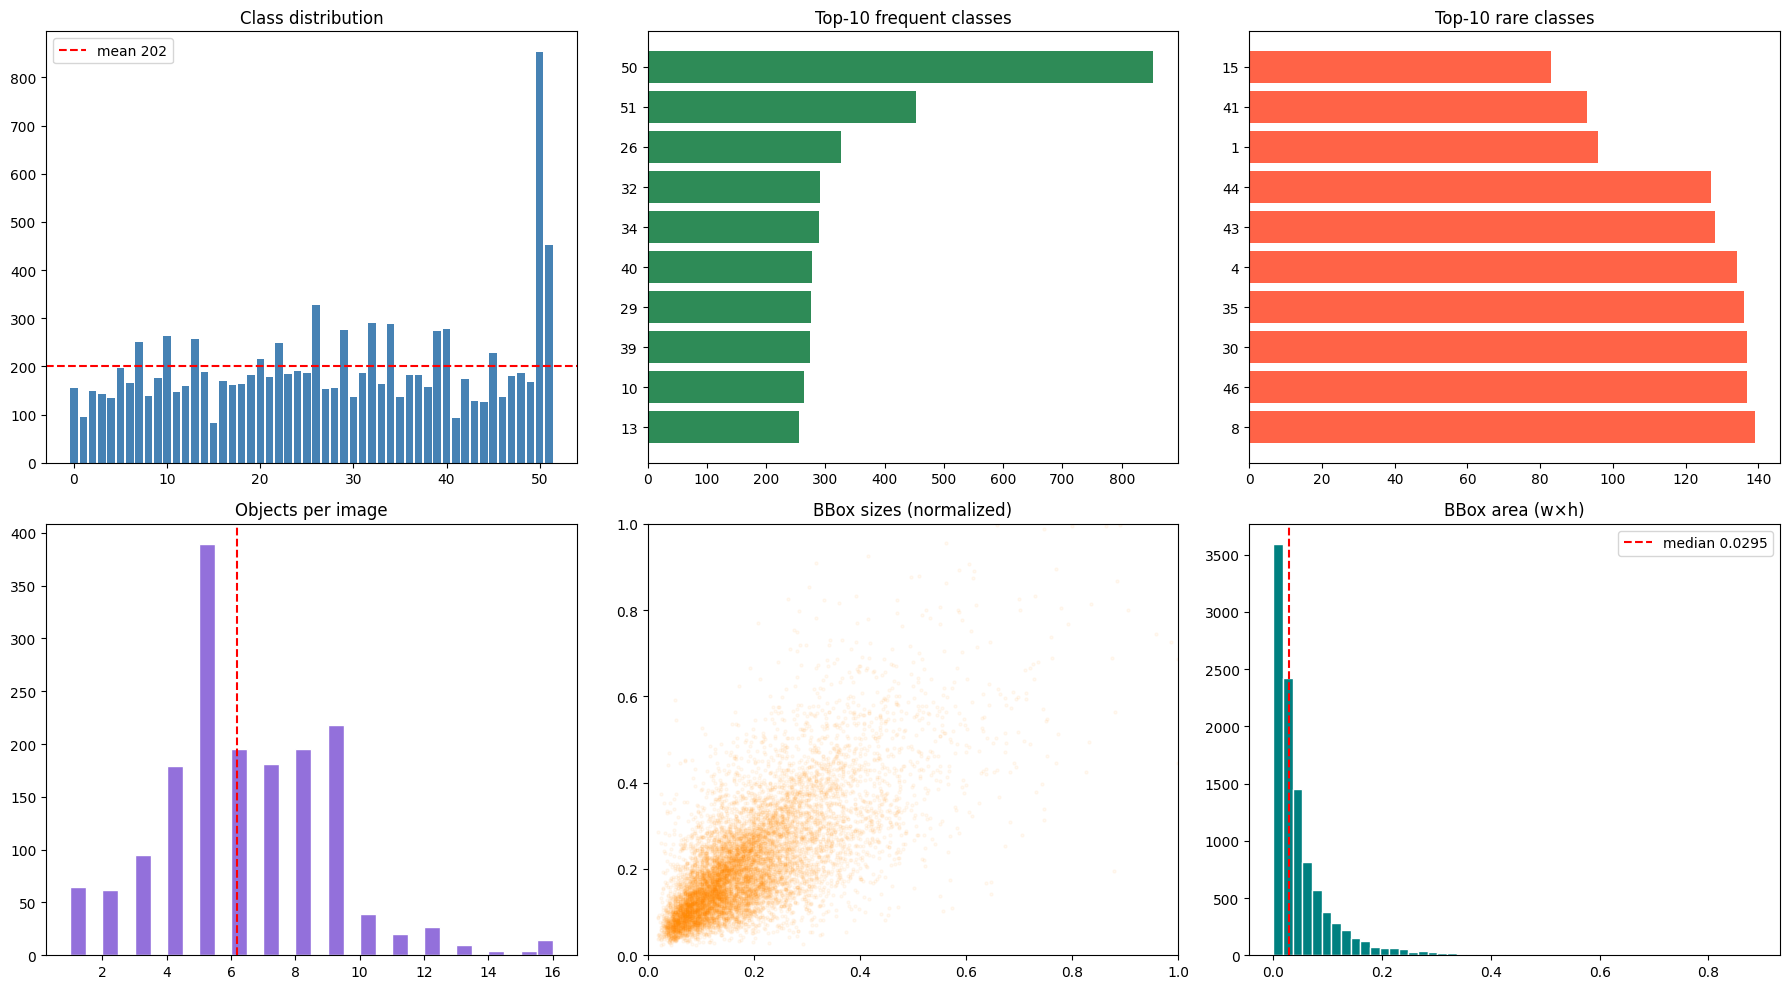

In [3]:
label_files = sorted(glob.glob(f'{LABELS_DIR}/*.txt'))
image_files = sorted(glob.glob(f'{IMAGES_DIR}/*.jpg') + glob.glob(f'{IMAGES_DIR}/*.png'))

records = []
per_image_counts = []

for lf in label_files:
    with open(lf) as f:
        lines = [l.strip() for l in f if l.strip()]
    per_image_counts.append(len(lines))
    for line in lines:
        parts = line.split()
        if len(parts) == 5:
            cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
            records.append((cls, xc, yc, w, h))

df = pd.DataFrame(records, columns=['class_id','x_center','y_center','width','height'])
df['area'] = df['width'] * df['height']

print(f'Total objects      : {len(df)}')
print(f'Unique classes     : {df["class_id"].nunique()}')
print(f'Missing classes    : {sorted(set(range(52)) - set(df["class_id"].unique()))}')
print(f'Avg objects/image  : {np.mean(per_image_counts):.1f}')
print(f'Median bbox area   : {df["area"].median():.4f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

class_counts = df['class_id'].value_counts().sort_index()

axes[0,0].bar(class_counts.index, class_counts.values, color='steelblue', width=0.8)
axes[0,0].axhline(class_counts.mean(), color='red', linestyle='--', label=f'mean {class_counts.mean():.0f}')
axes[0,0].set_title('Class distribution'); axes[0,0].legend()

top10 = class_counts.nlargest(10)
axes[0,1].barh(top10.index.astype(str), top10.values, color='seagreen')
axes[0,1].set_title('Top-10 frequent classes'); axes[0,1].invert_yaxis()

bot10 = class_counts.nsmallest(10)
axes[0,2].barh(bot10.index.astype(str), bot10.values, color='tomato')
axes[0,2].set_title('Top-10 rare classes'); axes[0,2].invert_yaxis()

axes[1,0].hist(per_image_counts, bins=30, color='mediumpurple', edgecolor='white')
axes[1,0].axvline(np.mean(per_image_counts), color='red', linestyle='--')
axes[1,0].set_title('Objects per image')

axes[1,1].scatter(df['width'], df['height'], alpha=0.05, s=5, color='darkorange')
axes[1,1].set_title('BBox sizes (normalized)'); axes[1,1].set_xlim(0,1); axes[1,1].set_ylim(0,1)

axes[1,2].hist(df['area'], bins=50, color='teal', edgecolor='white')
axes[1,2].axvline(df['area'].median(), color='red', linestyle='--',
                  label=f'median {df["area"].median():.4f}')
axes[1,2].set_title('BBox area (w×h)'); axes[1,2].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

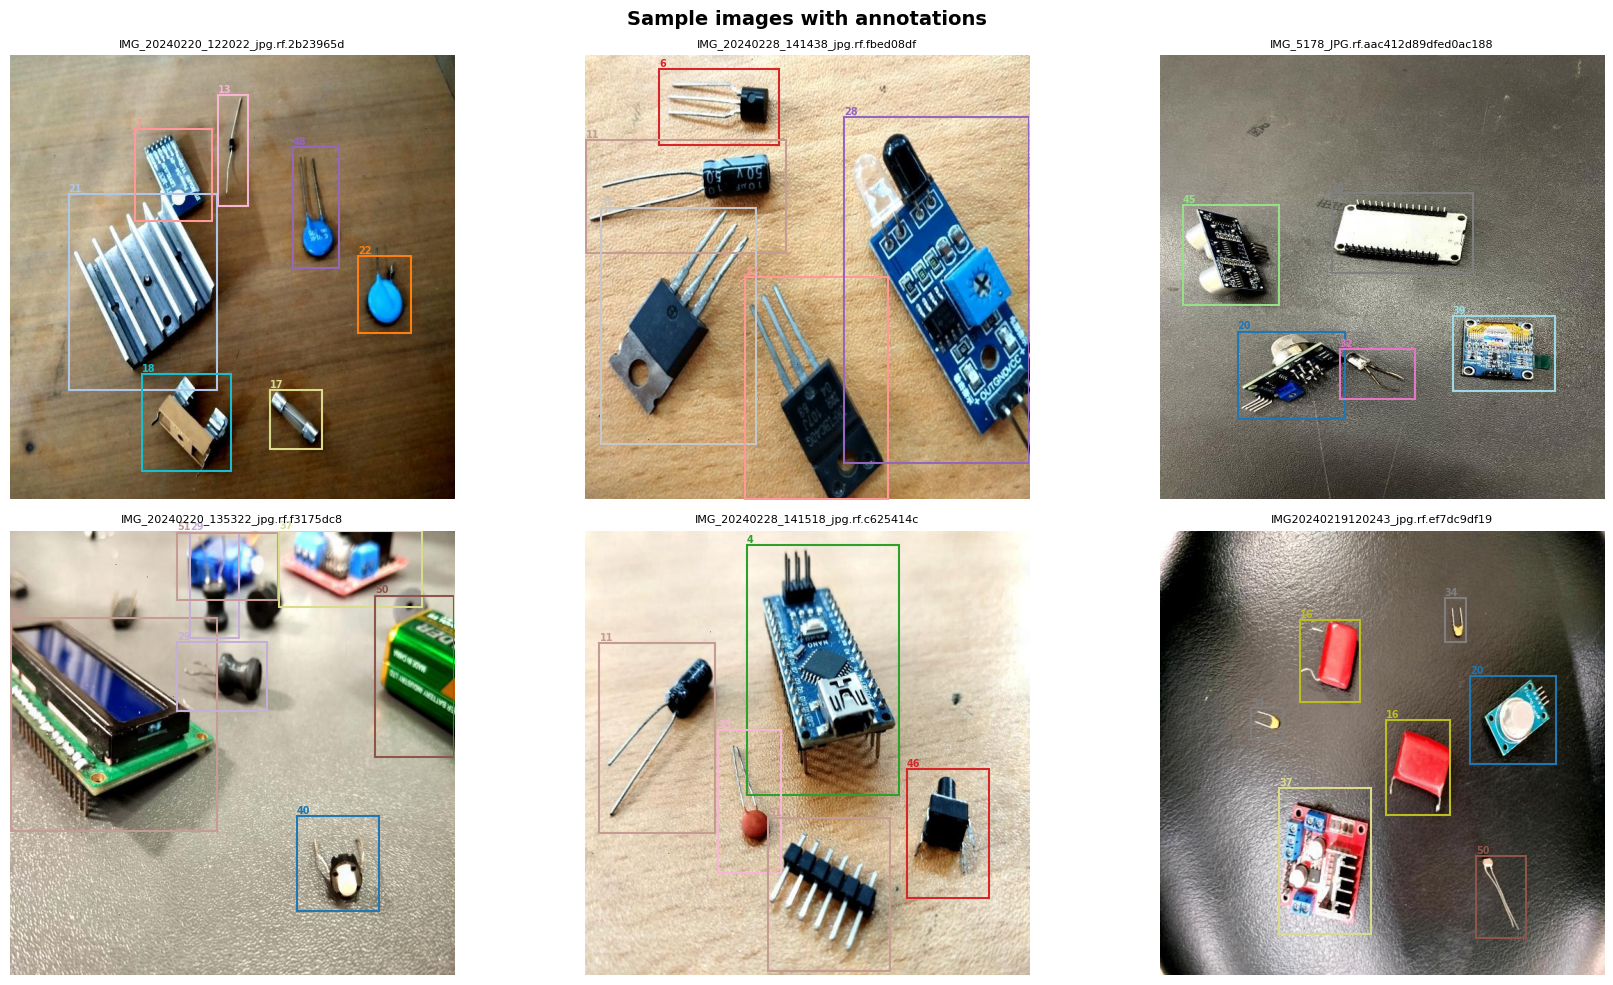

In [4]:
np.random.seed(SEED)
sample_imgs = np.random.choice(image_files, 6, replace=False)
cmap = plt.colormaps.get_cmap('tab20')

fig2, axes2 = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle('Sample images with annotations', fontsize=14, fontweight='bold')

for ax, img_path in zip(axes2.flat, sample_imgs):
    img = Image.open(img_path)
    W, H = img.size
    ax.imshow(img)
    lbl = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    if os.path.exists(lbl):
        with open(lbl) as f:
            for line in f:
                p = line.strip().split()
                if len(p) == 5:
                    cls = int(p[0])
                    xc, yc, bw, bh = map(float, p[1:])
                    x1 = (xc - bw/2) * W; y1 = (yc - bh/2) * H
                    rect = patches.Rectangle((x1,y1), bw*W, bh*H,
                                             linewidth=1.5, edgecolor=cmap(cls % 20), facecolor='none')
                    ax.add_patch(rect)
                    ax.text(x1, y1-3, str(cls), color=cmap(cls % 20), fontsize=7, fontweight='bold')
    ax.axis('off')
    ax.set_title(os.path.basename(img_path)[:35], fontsize=8)

plt.tight_layout()
plt.savefig('eda_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Prepare Dataset (Train/Val Split)

In [5]:
image_ids, dominant_cls = [], []

for lf in label_files:
    stem = os.path.splitext(os.path.basename(lf))[0]
    image_ids.append(stem)
    with open(lf) as f:
        classes = [int(l.split()[0]) for l in f if l.strip()]
    dominant_cls.append(Counter(classes).most_common(1)[0][0] if classes else 0)

train_ids, val_ids = train_test_split(
    image_ids, test_size=0.2, random_state=SEED, stratify=dominant_cls)

print(f'Train: {len(train_ids)}  |  Val: {len(val_ids)}')

for split in ['train', 'val']:
    os.makedirs(f'{BASE_DIR}/{split}/images', exist_ok=True)
    os.makedirs(f'{BASE_DIR}/{split}/labels', exist_ok=True)

def copy_split(ids, split):
    for stem in ids:
        for ext in ['.jpg', '.png', '.jpeg']:
            src = f'{IMAGES_DIR}/{stem}{ext}'
            if os.path.exists(src):
                shutil.copy2(src, f'{BASE_DIR}/{split}/images/{stem}{ext}')
                break
        src_lbl = f'{LABELS_DIR}/{stem}.txt'
        if os.path.exists(src_lbl):
            shutil.copy2(src_lbl, f'{BASE_DIR}/{split}/labels/{stem}.txt')

copy_split(train_ids, 'train')
copy_split(val_ids,   'val')

yaml_path = f'{BASE_DIR}/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump({
        'path' : BASE_DIR,
        'train': 'train/images',
        'val'  : 'val/images',
        'nc'   : 52,
        'names': [f'class_{i}' for i in range(52)]
    }, f, allow_unicode=True, sort_keys=False)

print(f'data.yaml saved: {yaml_path}')


Train: 1357  |  Val: 340
data.yaml saved: /kaggle/working/yolo_dataset/data.yaml


## 3.5. Data Augmentation

In [6]:
def make_augmented_copy(img, aug_type):
    img = img.copy()
    h, w = img.shape[:2]

    if aug_type == 'strong_noise':
        noise = np.random.normal(0, random.uniform(35, 65), img.shape).astype(np.int16)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    elif aug_type == 'stripes':
        if random.random() > 0.4:
            t = random.randint(2, 5)
            x = w // 2 + random.randint(-40, 40)
            img[:, x:x+t] = (img[:, x:x+t] * 0.5).astype(np.uint8)
        for _ in range(random.randint(1, 4)):
            y = random.randint(0, h - 1)
            t = random.randint(1, 3)
            img[y:y+t, :] = (img[y:y+t, :] * 0.25).astype(np.uint8)

    elif aug_type == 'motion_blur':
        size = random.choice([9, 13, 17, 21])
        kernel = np.zeros((size, size))
        kernel[size // 2, :] = 1.0 / size
        img = cv2.filter2D(img, -1, kernel)

    elif aug_type == 'combined_bw':
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (7, 7), 0)
        gray = cv2.convertScaleAbs(gray, alpha=random.uniform(0.45, 0.7), beta=0)
        img = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    elif aug_type == 'jpeg_compress':
        _, enc = cv2.imencode('.jpg', img, [cv2.IMWRITE_JPEG_QUALITY, random.randint(20, 45)])
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    return img


orig_images = [p for p in glob.glob(f'{BASE_DIR}/train/images/*.jpg')
               if not os.path.basename(p).startswith('aug_')]

AUG_PLAN = {
    'strong_noise':  orig_images,
    'stripes':       orig_images,
    'motion_blur':   orig_images,
    'combined_bw':   orig_images[::2],
    'jpeg_compress': orig_images[1::2],
}

for aug_type, source_list in AUG_PLAN.items():
    for img_path in source_list:
        img = cv2.imread(img_path)
        stem = os.path.splitext(os.path.basename(img_path))[0]
        out_stem = f'aug_{aug_type}_{stem}'
        cv2.imwrite(f'{BASE_DIR}/train/images/{out_stem}.jpg', make_augmented_copy(img, aug_type))
        lbl_src = f'{BASE_DIR}/train/labels/{stem}.txt'
        if os.path.exists(lbl_src):
            shutil.copy(lbl_src, f'{BASE_DIR}/train/labels/{out_stem}.txt')

total = len(glob.glob(f'{BASE_DIR}/train/images/*.jpg'))
print(f'Итого: {total} изображений')

Итого: 6785 изображений


## 4. Training

In [ ]:
if os.path.exists('/kaggle/input') and torch.cuda.is_available():
    PROJECT_DIR = '/kaggle/working/runs'
    DEVICE      = [0, 1] if torch.cuda.device_count() > 1 else 0
    WORKERS     = 4
elif torch.cuda.is_available():
    PROJECT_DIR = './runs'
    DEVICE      = 0
    WORKERS     = 2
else:
    PROJECT_DIR = './runs'
    DEVICE      = 'cpu'
    WORKERS     = 2

print(f'Device: {DEVICE}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'GPU count: {torch.cuda.device_count()}')

model = YOLO('yolov8m.pt')
model.train(
    data         = yaml_path,
    epochs       = 100,
    imgsz        = 640,
    batch        = 16,
    seed         = SEED,
    optimizer    = 'AdamW',
    lr0          = 0.001,
    weight_decay = 0.0005,
    mosaic       = 1.0,
    mixup        = 0.15,
    copy_paste   = 0.3,
    fliplr       = 0.5,
    flipud       = 0.2,
    degrees      = 30.0,
    perspective  = 0.001,
    scale        = 0.5,
    hsv_h        = 0.02,
    hsv_s        = 0.8,
    hsv_v        = 0.6,
    erasing      = 0.5,
    patience     = 20,
    project      = PROJECT_DIR,
    name         = f'go2026_{VERSION}',
    save_period  = 10,
    device       = DEVICE,
    workers      = WORKERS,
    verbose      = True,
)

best_model = YOLO(f'{PROJECT_DIR}/go2026_{VERSION}/weights/best.pt')

Device: [0, 1]
CUDA available: True
GPU count: 2
Ultralytics 8.4.43 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=30.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.5, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.8, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=

## 5. Validation Results

In [ ]:
best_model = YOLO(f'{PROJECT_DIR}/go2026_{VERSION}/weights/best.pt')

In [ ]:
best_model = YOLO(f'{PROJECT_DIR}/go2026_{VERSION}/weights/best.pt')
metrics = best_model.val(data=yaml_path, verbose=False)

print(f'mAP50     : {metrics.box.map50:.4f}')
print(f'mAP50-95  : {metrics.box.map:.4f}')
print(f'Precision : {metrics.box.mp:.4f}')
print(f'Recall    : {metrics.box.mr:.4f}')

maps_per_class = metrics.box.maps
df_cls = pd.DataFrame({'class_id': range(52), 'mAP50': maps_per_class})
print(f'\nWorst 10 classes:')
print(df_cls.nsmallest(10, 'mAP50').to_string(index=False))


## 6. Inference & Postprocessing

In [ ]:
test_images = sorted(glob.glob(f'{TEST_PATH}/images/*.jpg'))
print(f'Тестовых изображений: {len(test_images)}')

sample = pd.read_csv(SAMPLE_PATH)
CONF = 0.0001

results_list = []
for img_path in test_images:
    image_id = os.path.splitext(os.path.basename(img_path))[0]
    preds = best_model.predict(
        source  = img_path,
        conf    = CONF,
        iou     = 0.5,
        augment = True,
        verbose = False
    )
    boxes = preds[0].boxes
    if boxes is None or len(boxes) == 0:
        pred_str = '50 0.25 100 100 500 500'
    else:
        parts = []
        for box in boxes:
            cls  = int(box.cls.item())
            conf = round(float(box.conf.item()), 4)
            x1, y1, x2, y2 = [round(v) for v in box.xyxy[0].tolist()]
            parts.extend([cls, conf, x1, y1, x2, y2])
        pred_str = ' '.join(map(str, parts))
    results_list.append({'image_id': image_id, 'PredictionString': pred_str})

df_sub = pd.DataFrame(results_list)
df_final = sample[['image_id']].merge(df_sub, on='image_id', how='left')
df_final['PredictionString'] = df_final['PredictionString'].fillna('50 0.25 100 100 500 500')

out_path = f'/kaggle/working/sample_submission.csv' if os.path.exists('/kaggle/input') else f'./sample_submission.csv'
df_final.to_csv(out_path, index=False)
print(f' Готово: {len(df_final)} строк → {out_path}')


In [ ]:
print(df_final.head(3).to_string())

## 7. Save Weights to Drive

In [ ]:
# Веса модели находятся по пути:
weights_path = f'{PROJECT_DIR}/go2026_{VERSION}/weights/best.pt'
print(f'Веса: {weights_path}')
print(f'Submission: {out_path}')
